In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
# using the same seed for reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["LOKY_MAX_CPU_COUNT"] = "10"

### Load the data

In [13]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3,HalogenCount,SulfurCount,...,FP_2032,FP_2033,FP_2034,FP_2036,FP_2040,FP_2041,FP_2042,FP_2044,FP_2046,pIC50
0,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.619789
1,423.463,4.48660,2.0,4.0,70.56,5.0,2.0,0.291667,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.366532
2,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.508638
3,401.510,4.51682,2.0,4.0,70.56,5.0,2.0,0.320000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.420216
4,405.473,4.34750,2.0,4.0,70.56,5.0,2.0,0.291667,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.698970


#### Preparing Features and Target Variables and Checking Their Shapes

In [14]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (13335, 1102)
Shape of Y: (13335,)


#### Splitting the data into train and validation (80:20)

Note: Feature selection (Variance Threshold + Correlation Filter) was already applied in the Data Preprocessing notebook. The `train_data.csv` loaded here contains only the pre-selected 1,102 features,no further feature removal is needed.

In [15]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(X, Y, test_size=0.2, random_state=42)

#### Scaling the data

Neural networks are sensitive to feature scale. `StandardScaler` is applied to both features (`scaler_x`) and the target (`scaler_y`),fit only on training data to prevent data leakage. Predictions are inverse-transformed back to pIC50 scale before computing metrics.

In [16]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_us)
X_val = scaler_x.transform(X_val_us)

scaler_y = StandardScaler()
Y_train = scaler_y.fit_transform(Y_train_us.values.reshape(-1, 1)).flatten()
Y_val = scaler_y.transform(Y_val_us.values.reshape(-1, 1)).flatten()

print("Shape of X_train:", X_train.shape, "Shape of Y_train:", Y_train.shape)
print("Shape of X_val:", X_val.shape, "Shape of Y_val:", Y_val.shape)

Shape of X_train: (10668, 1102) Shape of Y_train: (10668,)
Shape of X_val: (2667, 1102) Shape of Y_val: (2667,)


### Simple Neural Network model

A Sequential model with 4 hidden layers (512→256→128→64 units, ReLU activation), BatchNormalization for training stability, Dropout for regularisation, and a linear output layer for regression. Input dimension matches the 1,102 pre-selected features from preprocessing.

**BatchNormalization placement note:** In this model, BatchNormalization is applied *after* the ReLU activation (post-activation style). The ResNet in `resNetwork.ipynb` uses the *pre-activation* style (Dense → BN → ReLU), as proposed by He et al. (2016, *Identity Mappings in Deep Residual Networks*), which is theoretically preferred for gradient flow. Both approaches work in practice; the difference is documented here for transparency.


In [17]:
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),  
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(1,   activation='linear'),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       564,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,353 (2.82 MB)

 Trainable params: 738,817 (2.82 MB)

 Non-trainable params: 1,536 (6.00 KB)

Defining loss function , optimizer and metrics to track during training

The model is compiled with the **Adam** optimizer (lr=0.001),preferred over SGD for high-dimensional sparse fingerprint data as it adapts the learning rate per-parameter and converges faster. Loss is Mean Squared Error; RMSE and R² are tracked as evaluation metrics. `EarlyStopping` (patience=20) halts training when validation loss stops improving and restores the best weights.

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['RootMeanSquaredError', 'r2_score']
)

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0      
)

results = model.evaluate(X_val, Y_val, verbose=0)
print(f"Baseline NN_Val Loss: {results[0]:.4f}, RMSE: {results[1]:.4f}, R²: {results[2]:.4f}")

Epoch 103: early stopping
Restoring model weights from the end of the best epoch: 53.
Baseline NN — Val Loss: 0.2986, RMSE: 0.5464, R²: 0.7086


Plotting the training curves

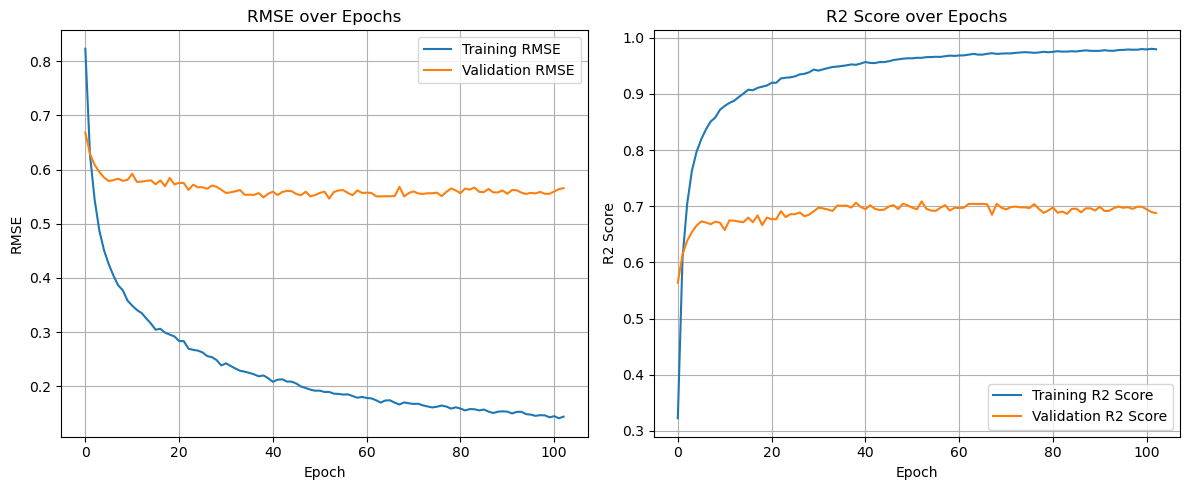

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['RootMeanSquaredError'], label='Training RMSE')
axes[0].plot(history.history['val_RootMeanSquaredError'], label='Validation RMSE')
axes[0].set_title('RMSE over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['r2_score'], label='Training R2 Score')
axes[1].plot(history.history['val_r2_score'], label='Validation R2 Score')
axes[1].set_title('R2 Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Observation:**
- RMSE decreases progressively over training epochs,the model is learning.
- A gap between validation RMSE and training RMSE indicates overfitting on the training set.
- EarlyStopping prevents over-training and restores the best generalising weights.
- Dropout and BatchNormalization layers are added in the next model to reduce this gap.

### Model with dropout layers

Higher Dropout rates (0.4→0.3→0.2) and BatchNormalization are added to aggressively regularise the model. `ReduceLROnPlateau` monitors validation loss and halves the learning rate when improvements stall, enabling finer convergence.

In [27]:
model_dropout = Sequential([
    keras.Input(shape=(X_train.shape[1],)),  
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dense(1,   activation='linear'),
])
model_dropout.summary()

model_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['RootMeanSquaredError', 'r2_score']
)

early_stop_do = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
lr_scheduler  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

history_dropout = model_dropout.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop_do, lr_scheduler],
    verbose=0
)

results_do = model_dropout.evaluate(X_val, Y_val, verbose=0)
print(f"Dropout NN_Val Loss: {results_do[0]:.4f}, RMSE: {results_do[1]:.4f}, R²: {results_do[2]:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       564,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,353 (2.82 MB)

 Trainable params: 738,817 (2.82 MB)

 Non-trainable params: 1,536 (6.00 KB)

KeyboardInterrupt: 

Plotting the Train and Validation loss

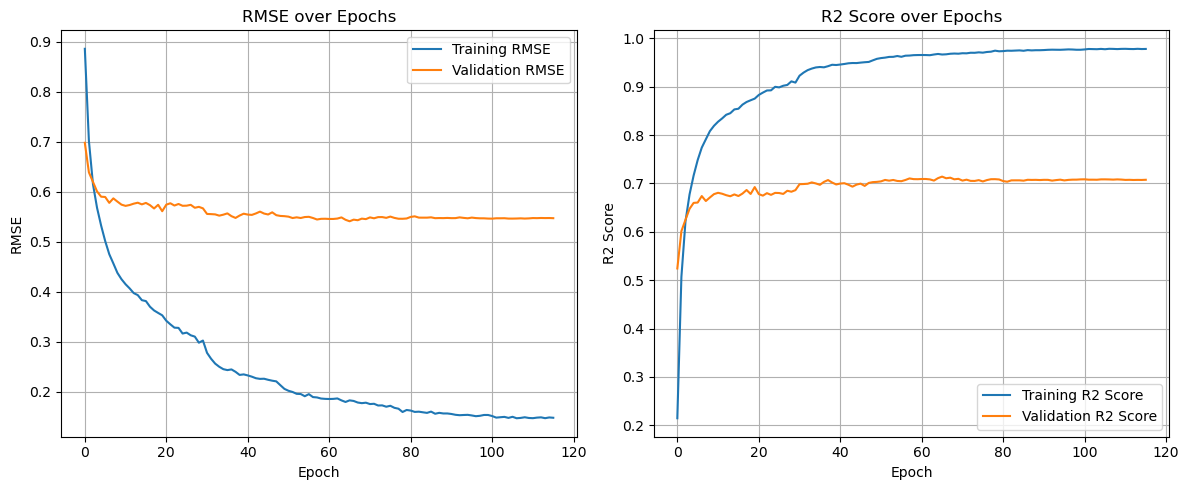

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_dropout.history['RootMeanSquaredError'], label='Training RMSE')
axes[0].plot(history_dropout.history['val_RootMeanSquaredError'], label='Validation RMSE')
axes[0].set_title('RMSE over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_dropout.history['r2_score'], label='Training R2 Score')
axes[1].plot(history_dropout.history['val_r2_score'], label='Validation R2 Score')
axes[1].set_title('R2 Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Observation:**
- RMSE decreases with epoch and the gap between training and validation RMSE is smaller than the baseline model.
- Dropout and BatchNormalization together reduce overfitting significantly.
- `ReduceLROnPlateau` enables smoother convergence in later epochs when the learning rate is reduced.

### Test Data

### Load Test Data

In [22]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (3651, 1102)
Shape of Y_test: (3651,)


Scaling the test set using the same `scaler_x` fitted on training data, no re-fitting to prevent data leakage. Feature selection was already applied in preprocessing so `test_data.csv` has matching columns.

#### Feature selection was applied in preprocessing,test_data.csv already has matching columns

In [23]:
X_test_scaled = scaler_x.transform(X_test)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_test_scaled: (3651, 1102)


Evaluating RMSE, MAE, and R² on the test set for both models. Predictions are inverse-transformed from the scaled target space back to original pIC50 units before computing metrics.

In [24]:
# --- Baseline NN ---
y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

model_test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))
model_test_mae  = mean_absolute_error(Y_test, y_test_pred)
model_test_r2   = r2_score(Y_test, y_test_pred)

# --- Dropout NN ---
y_test_pred_dropout_scaled = model_dropout.predict(X_test_scaled, verbose=0)
y_test_pred_dropout = scaler_y.inverse_transform(y_test_pred_dropout_scaled).flatten()

model_test_rmse_dropout = np.sqrt(mean_squared_error(Y_test, y_test_pred_dropout))
model_test_mae_dropout  = mean_absolute_error(Y_test, y_test_pred_dropout)
model_test_r2_dropout   = r2_score(Y_test, y_test_pred_dropout)

print("Test Set Performance (scaffold-based split, chemically distinct molecules):")
print(f"\nBaseline NN:")
print(f"  RMSE : {model_test_rmse:.4f}")
print(f"  MAE  : {model_test_mae:.4f}")
print(f"  R²   : {model_test_r2:.4f}")

print(f"\nDropout NN:")
print(f"  RMSE : {model_test_rmse_dropout:.4f}")
print(f"  MAE  : {model_test_mae_dropout:.4f}")
print(f"  R²   : {model_test_r2_dropout:.4f}")

Test Set Performance (scaffold-based split — chemically distinct molecules):

Baseline NN:
  RMSE : 0.9577
  MAE  : 0.6766
  R²   : 0.5637

Dropout NN:
  RMSE : 0.9412
  MAE  : 0.6653
  R²   : 0.5787


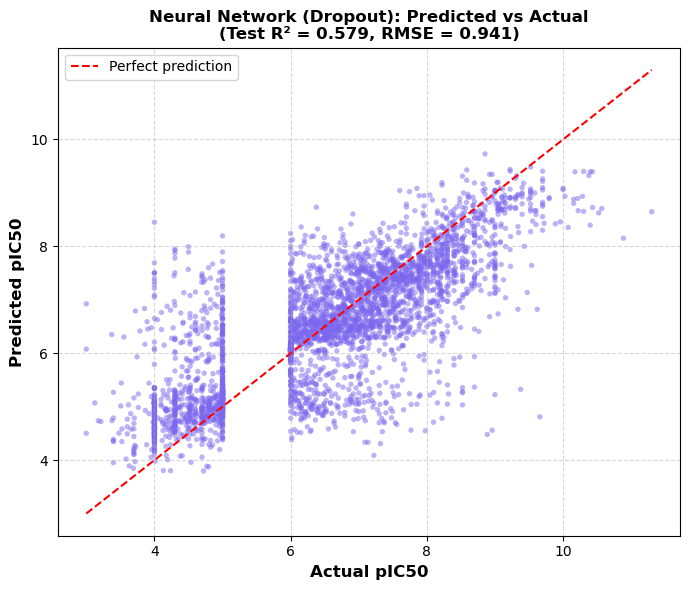

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Y_test, y_test_pred_dropout, alpha=0.5, color='mediumslateblue', edgecolors='none', s=15)
lims = [min(Y_test.min(), y_test_pred_dropout.min()),
        max(Y_test.max(), y_test_pred_dropout.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_title(f'Neural Network (Dropout): Predicted vs Actual\n'
             f'(Test R² = {model_test_r2_dropout:.3f}, RMSE = {model_test_rmse_dropout:.3f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation:** Points near the diagonal indicate correct predictions. Scatter at the extremes (very low/high pIC50) is expected on a scaffold-based test set, as the model has not seen molecules with those scaffolds during training. The Dropout model generally shows a tighter cluster around the diagonal than the baseline model.

Saving the test RMSE and R² score for final comparison in the Results notebook.

In [26]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("Model_NN", model_test_rmse, model_test_r2)
save_model_info("Model_NN_Dropout", model_test_rmse_dropout, model_test_r2_dropout)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code